## 教程二：使用 VQE 算法求解分子基态

本教程将详细展示如何利用 变分量子本征求解器（Variational Quantum Eigensolver, VQE） 在活性空间近似下求解 H₂ 分子的基态能量。我们将从基本原理出发，逐步介绍梯度计算、哈密顿量构造、ansatz 结构、优化流程及结果分析。示例中的代码可直接在 Jupyter Book 环境中运行。与 VarQITE 不同，VQE 采用经典优化器在参数空间中最小化能量期望值，是最经典的混合量子‑经典算法之一。

### 1. 算法原理：变分量子本征求解器 (VQE)

#### 1.1 Rayleigh‑Ritz 变分原理

对于任一归一化的试探波函数 $|\psi\rangle $ ，有如下不等式：
$$ \langle\psi|H|\psi\rangle ≥E_0$$
其中 $E_0$ 为系统的真实基态能量，$H$ 为系统哈密顿量，等号当且仅当 $|\psi\rangle $ 恰好是基态时成立。VQE 正是利用这一原理，通过一个参数化量子电路构造试探态，并在经典计算机的辅助下寻找使能量期望值最小化的参数 $\theta^*$：
$$ \boldsymbol{\theta}^{*}=\arg\min_{\boldsymbol{\theta}}E(\boldsymbol{\theta}),\quad E(\boldsymbol{\theta})=\langle\psi(\boldsymbol{\theta})|H|\psi(\boldsymbol{\theta})\rangle \quad(1)$$

#### 1.2 能量期望值的测量
通常，分子哈密顿量经 Jordan‑Wigner 变换等项目化处理后被表示为 Pauli 串的加权和：
$$ H=\sum_{k=1}^M\alpha_kP_k,\quad P_k\in\{I,X,Y,Z\}^{\otimes n} \quad(2)$$
因此能量期望值可以分解为各项 Pauli 期望值的加权和：
$$ E(\boldsymbol{\theta})=\sum_{k=1}^M\alpha_k\langle\psi(\boldsymbol{\theta})|P_k|\psi(\boldsymbol{\theta})\rangle \quad(3)$$
在真实量子处理器上，每一项 $\langle P_{k}\rangle $ 可以通过多次测量并统计结果获得；而在数值模拟中可以直接用波函数计算。VQE 将量子计算机视为一个“能量计算黑箱”，经典优化器则基于返回的能量值调整参数。

#### 1.3 梯度计算与参数平移法则
为保证优化效率，常需要使用梯度信息。若 ansatz 中的参数只出现在形如 $e^{-i\theta G/2} $ 的单比特或双比特旋转门中（其中 $G$ 是 Pauli 矩阵），可用参数平移法则精确计算解析梯度。以 $ R_y(\theta)=e^{-i\theta Y/2}$ 为例：
$$ \frac{\partial}{\partial\theta}\langle\psi(\theta)|H|\psi(\theta)\rangle=\frac{1}{2}\left[E\left(\theta+\frac{\pi}{2}\right)-E\left(\theta-\frac{\pi}{2}\right)\right] \quad(4)$$
更一般地，对于任意 Pauli 生成元 $G$ ，只需平移 $±π/2$ 即可得到梯度。这一方法在硬件上易于实现，同时避免了有限差分引起的数值误差。本框架同时支持自动微分 (autograd) 和参数平移两种模式，用户可根据需要选择。

#### 1.4 经典优化器与迭代流程
VQE 通常采用梯度下降或其变体（如 Adam）更新参数：
$$ \boldsymbol{\theta}_{t+1}=\boldsymbol{\theta}_t-\eta\nabla E(\boldsymbol{\theta}_t) \quad(5)$$
其中 $η$ 为学习率。迭代直至能量收敛到预设精度或达到最大步数。

### 2. 分子结构与哈密顿量
#### 2.1 H₂ 分子几何构型

氢气分子由两个氢原子组成，键长约为 0.74 Å。在此教程中，我们将其定义为：

In [1]:
h2_geometry = [[0.0, 0.0, 0.0], [0.0, 0.0, 0.74]]

#### 2.2 活性空间近似与量子比特数
对于 H₂ 分子，采用 STO‑3G 最小基组时，每个氢原子提供 1 个 1s 轨道，共 2 个空间轨道，对应于 4 个自旋轨道。若进行全轨道模拟，需要 4 个量子比特。本例中我们进一步使用活性空间近似，仅选取 2 个活性电子、2 个活性轨道（即冻结一个轨道或者直接使用最小活性空间），此时仍然映射到 4 个量子比特。实际上，这就是该活性空间下的完整处理。

以下代码生成 qubit 哈密顿量：

In [2]:
import os
import torch
import matplotlib.pyplot as plt
from backends.Tensorcircuit import TensorCircuitBackend
from ansatz.HEA import HEAAnsatz
from solvers.vqe import VQESolver
from chemistry.hamiltonian import Hamiltonian

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["HYQ_BACKEND"] = "tensorcircuit"

h_obj_h2 = Hamiltonian(
    symbols=['H', 'H'],
    geometry=h2_geometry,
    charge=0,
    multiplicity=1
)

h_list_h2, n_q_h2, n_e_h2 = h_obj_h2.get_processed_hamiltonian(
    n_active_electrons=2,
    n_active_orbitals=2
)

print(f"H₂ 任务: Qubits={n_q_h2}, Electrons={n_e_h2}")

Please first ``pip install -U qiskit`` to enable related functionality in translation module


>>> [Hamiltonian] 正在调用 Psi4 计算分子积分...
>>> [Hamiltonian] 设置活性空间: 2e, 2orb
>>> [Hamiltonian] 原始算符项数: 15
H₂ 任务: Qubits=4, Electrons=2


得到的 **h_list_h2** 是一个包含类似 $(−1.05237,IIII),(0.39794,ZIII),… $ 的列表，每一项代表哈密顿量的 Pauli 项。

### 3. 硬件高效拟设 (HEA) 结构分解与电路图

VQE 的性能高度依赖于 ansatz 的表达能力。本例继续使用 硬件高效拟设 (HEA)，其结构简洁且易于在近期硬件上实现。我们对一个 4 量子比特、深度为 2 的 HEA 进行手动分解，并打印电路图以直观展示：

In [3]:
from backends.core import QuantumCircuit
import numpy as np

n_qubits = 4
depth = 2
total_params = n_qubits * (depth + 1)

# 生成示例参数（使用 Python float）
params = [0.1, 0.2, 0.3, 0.4,   # 第0层旋转
          0.5, 0.6, 0.7, 0.8,   # 第1层旋转
          0.9, 1.0, 1.1, 1.2]   # 最终层旋转

qc_hea = QuantumCircuit(n_qubits, name="HEA_H2")

param_idx = 0
for d in range(depth):
    # 旋转层 (Ry)
    for i in range(n_qubits):
        qc_hea.ry(i, params[param_idx])
        param_idx += 1
    # 纠缠层 (CNOT 线性链)
    for i in range(n_qubits - 1):
        qc_hea.cx(i, i + 1)

# 最后额外一层旋转
for i in range(n_qubits):
    qc_hea.ry(i, params[param_idx])
    param_idx += 1

print("[Visual] HEA Circuit Diagram (n_qubits=4, depth=2):")
print(qc_hea.draw(output='text', fold=-1))

[Visual] HEA Circuit Diagram (n_qubits=4, depth=2):
     ┌─────────┐     ┌─────────┐                      ┌─────────┐                    
q_0: ┤ Ry(0.1) ├──■──┤ Ry(0.5) ├────────────────■─────┤ Ry(0.9) ├────────────────────
     ├─────────┤┌─┴─┐└─────────┘┌─────────┐   ┌─┴─┐   └─────────┘┌───────┐           
q_1: ┤ Ry(0.2) ├┤ X ├─────■─────┤ Ry(0.6) ├───┤ X ├────────■─────┤ Ry(1) ├───────────
     ├─────────┤└───┘   ┌─┴─┐   └─────────┘┌──┴───┴──┐   ┌─┴─┐   └───────┘┌─────────┐
q_2: ┤ Ry(0.3) ├────────┤ X ├────────■─────┤ Ry(0.7) ├───┤ X ├───────■────┤ Ry(1.1) ├
     ├─────────┤        └───┘      ┌─┴─┐   ├─────────┤   └───┘     ┌─┴─┐  ├─────────┤
q_3: ┤ Ry(0.4) ├───────────────────┤ X ├───┤ Ry(0.8) ├─────────────┤ X ├──┤ Ry(1.2) ├
     └─────────┘                   └───┘   └─────────┘             └───┘  └─────────┘


由图可见，每一对 Ry 层和 CNOT 层交替堆叠，最后以一层 Ry 门收尾，这正是 HEA 的典型模式。

### 4. VQE 优化与收敛
现在正式调用 VQE 求解器。内置的优化器为 **Adam优化器**。我们使用与 示例一  类似的 HEA ansatz，深度设为 3（参数更多，表达能力更强）。

In [5]:
# 初始化后端与 ansatz
backend = TensorCircuitBackend()
ansatz_h2 = HEAAnsatz(n_qubits=n_q_h2, depth=3)
init_params_h2 = torch.randn(ansatz_h2.num_parameters, dtype=torch.float64) * 0.5

# 配置 VQE 求解器
vqe_solver = VQESolver(backend)

print(">>> 开始运行 VQE (Steps=160, LR=0.1)...")
_, _, vqe_hist = vqe_solver.solve(
    ansatz_h2,
    init_params_h2,
    h_list_h2,
    steps=160,
    lr=0.1
)

print(f"VQE 最终能量: {vqe_hist[-1]:.6f} Hartree")

>>> 开始运行 VQE (Steps=160, LR=0.1)...
--- VQE Start (Steps=160) ---
VQE Step 0: Energy = 0.417967
VQE Step 20: Energy = -1.057769
VQE Step 40: Energy = -1.111847
VQE Step 60: Energy = -1.120265
VQE Step 80: Energy = -1.123921
VQE Step 100: Energy = -1.126436
VQE Step 120: Energy = -1.130919
VQE Step 140: Energy = -1.135105
VQE Final Energy: -1.136666
VQE 最终能量: -1.136666 Hartree


能量从正值（初始参数随机）迅速降至约 −1.13 哈特里，接近该活性空间下 H₂ 分子的精确基态能量（FCI 值约为 −1.137 哈特里）。

### 5. 结果可视化
绘制阶梯图观察能量下降轨迹：

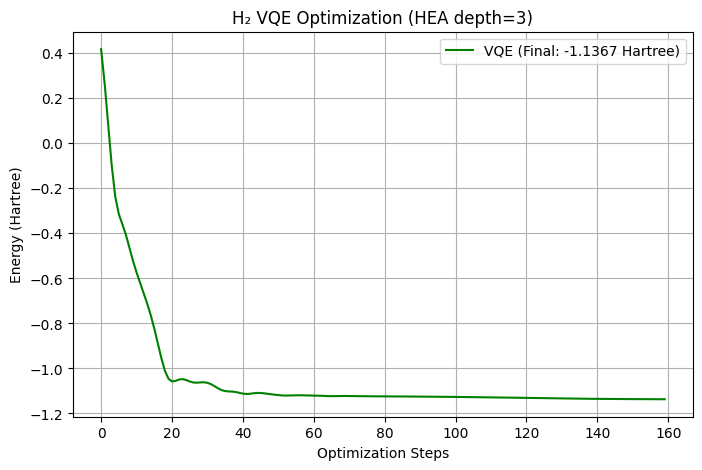

In [6]:
plt.figure(figsize=(8, 5))
plt.plot(vqe_hist, label=f'VQE (Final: {vqe_hist[-1]:.4f} Hartree)', color='g')
plt.title("H₂ VQE Optimization (HEA depth=3)")
plt.xlabel("Optimization Steps")
plt.ylabel("Energy (Hartree)")
plt.legend()
plt.grid(True)
plt.show()

曲线呈现典型的快速下降—缓慢逼近趋势，说明 Adam 优化器能有效利用梯度信息找到优质解。

### 6. 小结
本教程以 H₂ 分子为例，系统介绍了 VQE 算法的核心思想及实现细节：  

（1）基于 Rayleigh‑Ritz 变分原理，将能量期望值最小化问题转化为参数优化问题。  
（2）梯度可借助参数平移法则或自动微分精确计算。  
（3）利用 HEA ansatz 生成试探态，并通过经典优化器（Adam）迭代更新参数。  
（4）在活性空间近似下，仅用 4 量子比特便可模拟 H₂ 分子并获得与精确值接近的结果。  

VQE 是许多近期量子计算实验的首选算法，其模拟流程可直接推广至更复杂的分子和材料体系。在后续示例中，我们将继续展示 RQITE 和 SSQITE 等改进算法在相同分子上的表现。



### 7. 参考文献
Peruzzo, A., McClean, J., Shadbolt, P. et al. A variational eigenvalue solver on a photonic quantum processor. Nat Commun 5, 4213 (2014).